Carregando o Banco Mundial...


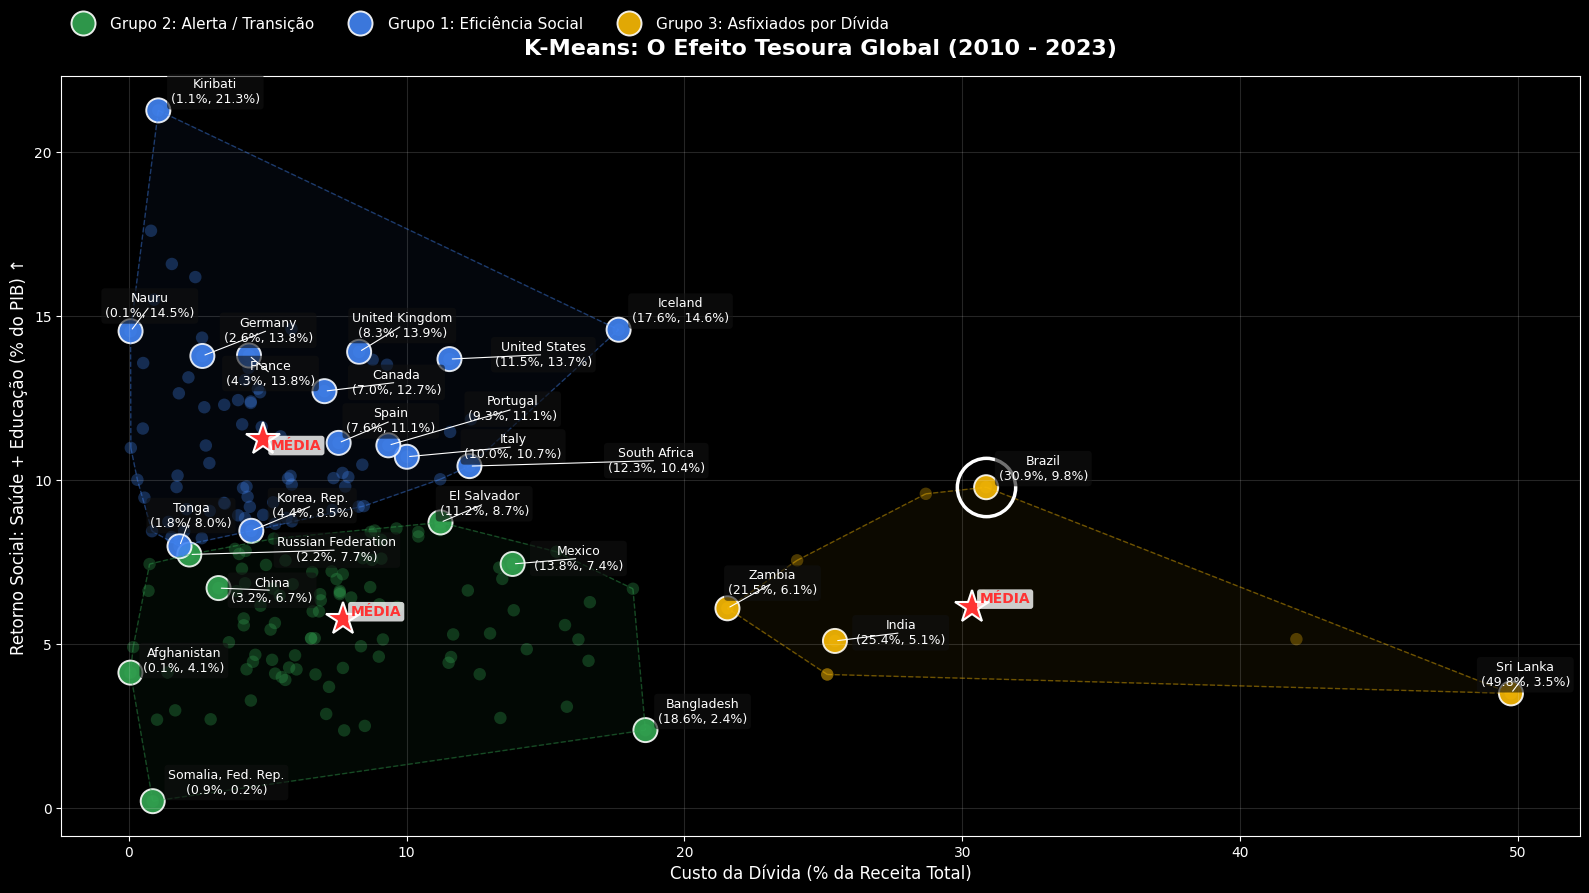


RELATÓRIO DE DESCOBERTA DO K-MEANS

[Grupo 1: Eficiência Social]
-> Quantidade de Países neste grupo: 80
-> Média de Gasto com Dívida: 4.8%
-> Média de Gasto Social: 11.3%
-> Quem são os líderes em juros deste grupo? Iceland, Costa Rica, South Africa, Argentina

[Grupo 2: Alerta / Transição]
-> Quantidade de Países neste grupo: 98
-> Média de Gasto com Dívida: 7.7%
-> Média de Gasto Social: 5.8%
-> Quem são os líderes em juros deste grupo? Bangladesh, Kenya, Dominican Republic, Malawi

[Grupo 3: Asfixiados por Dívida]
-> Quantidade de Países neste grupo: 10
-> Média de Gasto com Dívida: 30.3%
-> Média de Gasto Social: 6.1%
-> Quem são os líderes em juros deste grupo? Sri Lanka, Lebanon, Brazil, Ghana



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
from adjustText import adjust_text
import glob

print("Carregando o Banco Mundial...")
arq_edu = glob.glob('API_SE.XPD.TOTL.GD.ZS*.csv')
arq_sau = glob.glob('API_SH.XPD.GHED.GD.ZS*.csv')
arq_div = glob.glob('API_GC.XPN.INTP.RV.ZS*.csv')

df_edu = pd.read_csv(arq_edu[0], skiprows=4)
df_sau = pd.read_csv(arq_sau[0], skiprows=4)
df_div = pd.read_csv(arq_div[0], skiprows=4)

# 1. DEFINIÇÃO DO PERÍODO EXATO (2010 a 2023)
anos_analise = [str(ano) for ano in range(2010, 2024)]

# 2. CÁLCULO DA MÉDIA HISTÓRICA 
def calcular_media_periodo(df, nome_coluna):
    anos_validos = [ano for ano in anos_analise if ano in df.columns]
    df_resumo = df[['Country Code', 'Country Name']].copy()
    df_resumo[nome_coluna] = df[anos_validos].mean(axis=1)
    return df_resumo

edu = calcular_media_periodo(df_edu, 'Educacao_PIB')
sau = calcular_media_periodo(df_sau, 'Saude_PIB')
div = calcular_media_periodo(df_div, 'Pagamento_Total_Divida')

# Consolidando a base global limpa
df_global = edu.merge(sau, on=['Country Code', 'Country Name']).merge(div, on=['Country Code', 'Country Name'])
df_global['Gasto_Social'] = df_global['Educacao_PIB'] + df_global['Saude_PIB']
df_global = df_global.dropna()

# 3. K-MEANS 
X = df_global[['Pagamento_Total_Divida', 'Gasto_Social']]
X_padronizado = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_global['Cluster_ID'] = kmeans.fit_predict(X_padronizado)

# Nomenclatura Automática
centroides = df_global.groupby('Cluster_ID')[['Pagamento_Total_Divida', 'Gasto_Social']].mean()
id_baixo_juros = centroides['Pagamento_Total_Divida'].idxmin()
id_alto_juros = centroides['Pagamento_Total_Divida'].idxmax()
id_medio_juros = [i for i in range(3) if i not in [id_baixo_juros, id_alto_juros]][0]

df_global['Nome_Cluster'] = df_global['Cluster_ID'].map({
    id_baixo_juros: 'Grupo 1: Eficiência Social',
    id_medio_juros: 'Grupo 2: Alerta / Transição',
    id_alto_juros: 'Grupo 3: Asfixiados por Dívida'
})

# 4. A SELEÇÃO HÍBRIDA (Extremos + Países Famosos Limpos)
# Removidos: ARG, CHL, COL, URY para despoluir a visão
paises_conhecidos = [
    'BRA', 'USA', 'FRA', 'DEU', 'JPN', 'MEX', 
    'PRT', 'GBR', 'ITA', 'CAN', 'IND', 'ZAF', 'ESP', 'CHN', 'RUS', 'KOR'
]

df_destaque = pd.DataFrame()

for cid in df_global['Cluster_ID'].unique():
    grupo = df_global[df_global['Cluster_ID'] == cid]
    
    # 1. Limites espaciais (pontas)
    p_dir = grupo.nlargest(1, 'Pagamento_Total_Divida')
    p_esq = grupo.nsmallest(1, 'Pagamento_Total_Divida')
    p_top = grupo.nlargest(1, 'Gasto_Social')
    p_bot = grupo.nsmallest(1, 'Gasto_Social')
    extremos = pd.concat([p_dir, p_esq, p_top, p_bot]).drop_duplicates()
    
    # 2. Famosos do grupo
    famosos_do_grupo = grupo[grupo['Country Code'].isin(paises_conhecidos)]
    
    selecionados = pd.concat([extremos, famosos_do_grupo]).drop_duplicates()
    df_destaque = pd.concat([df_destaque, selecionados])

if 'BRA' not in df_destaque['Country Code'].values and 'BRA' in df_global['Country Code'].values:
    df_destaque = pd.concat([df_destaque, df_global[df_global['Country Code'] == 'BRA']])

# 5. CONSTRUÇÃO VISUAL 
plt.figure(figsize=(16, 9))
plt.style.use('dark_background')
cores = {'Grupo 1: Eficiência Social': '#4285F4', 'Grupo 2: Alerta / Transição': '#34A853', 'Grupo 3: Asfixiados por Dívida': '#FBBC05'}

sns.scatterplot(data=df_global, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=80, alpha=0.3, edgecolor='none', legend=False)
sns.scatterplot(data=df_destaque, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=300, alpha=0.9, edgecolor='white', legend='full')

for nome, grupo in df_global.groupby('Nome_Cluster'):
    pontos = grupo[['Pagamento_Total_Divida', 'Gasto_Social']].values
    if len(pontos) >= 3:
        hull = ConvexHull(pontos)
        for simplex in hull.simplices:
            plt.plot(pontos[simplex, 0], pontos[simplex, 1], color=cores[nome], linestyle='--', linewidth=1.0, alpha=0.4)
        plt.fill(pontos[hull.vertices, 0], pontos[hull.vertices, 1], color=cores[nome], alpha=0.05)

tabela_centroides = df_global.groupby('Nome_Cluster')[['Pagamento_Total_Divida', 'Gasto_Social']].mean()
textos_para_ajustar = []

for nome, row in tabela_centroides.iterrows():
    plt.plot(row['Pagamento_Total_Divida'], row['Gasto_Social'], marker='*', markersize=25, color='#FF3333', markeredgecolor='white', markeredgewidth=1.5, zorder=5)
    t = plt.text(row['Pagamento_Total_Divida'], row['Gasto_Social'], 'MÉDIA', fontsize=10, fontweight='bold', color='#FF3333',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"), zorder=6)
    textos_para_ajustar.append(t)

for i in range(df_destaque.shape[0]):
    t = plt.text(df_destaque['Pagamento_Total_Divida'].iloc[i], 
                 df_destaque['Gasto_Social'].iloc[i], 
                 f"{df_destaque['Country Name'].iloc[i]}\n({df_destaque['Pagamento_Total_Divida'].iloc[i]:.1f}%, {df_destaque['Gasto_Social'].iloc[i]:.1f}%)", 
                 fontsize=9, color='white',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#111111", alpha=0.6, ec="none"))
    textos_para_ajustar.append(t)

adjust_text(textos_para_ajustar, arrowprops=dict(arrowstyle='-', color='white', lw=0.8), max_iterations=50)

brasil_data = df_destaque[df_destaque['Country Code'] == 'BRA']
if not brasil_data.empty:
    plt.plot(brasil_data['Pagamento_Total_Divida'].values[0], brasil_data['Gasto_Social'].values[0], 'o', ms=42, mec='white', mfc='none', mew=2.5)

plt.title('K-Means: O Efeito Tesoura Global (2010 - 2023)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Custo da Dívida (% da Receita Total)', fontsize=12)
plt.ylabel('Retorno Social: Saúde + Educação (% do PIB) ↑', fontsize=12)
plt.legend(bbox_to_anchor=(0, 1.05), loc='lower left', borderaxespad=0, ncol=3, frameon=False, fontsize=11)
plt.grid(True, alpha=0.15)
plt.tight_layout()

plt.show()

# 6. RELATÓRIO TEXTUAL 
print("\n" + "="*60)
print("RELATÓRIO DE DESCOBERTA DO K-MEANS")
print("="*60)

for nome_grupo in sorted(df_global['Nome_Cluster'].unique()):
    grupo = df_global[df_global['Nome_Cluster'] == nome_grupo]
    lideres = grupo.nlargest(4, 'Pagamento_Total_Divida')['Country Name'].tolist()
    
    print(f"\n[{nome_grupo}]")
    print(f"-> Quantidade de Países neste grupo: {len(grupo)}")
    print(f"-> Média de Gasto com Dívida: {grupo['Pagamento_Total_Divida'].mean():.1f}%")
    print(f"-> Média de Gasto Social: {grupo['Gasto_Social'].mean():.1f}%")
    print(f"-> Quem são os líderes em juros deste grupo? {', '.join(lideres)}")
    
print("\n" + "="*60)

Carregando o Banco Mundial inteiro...


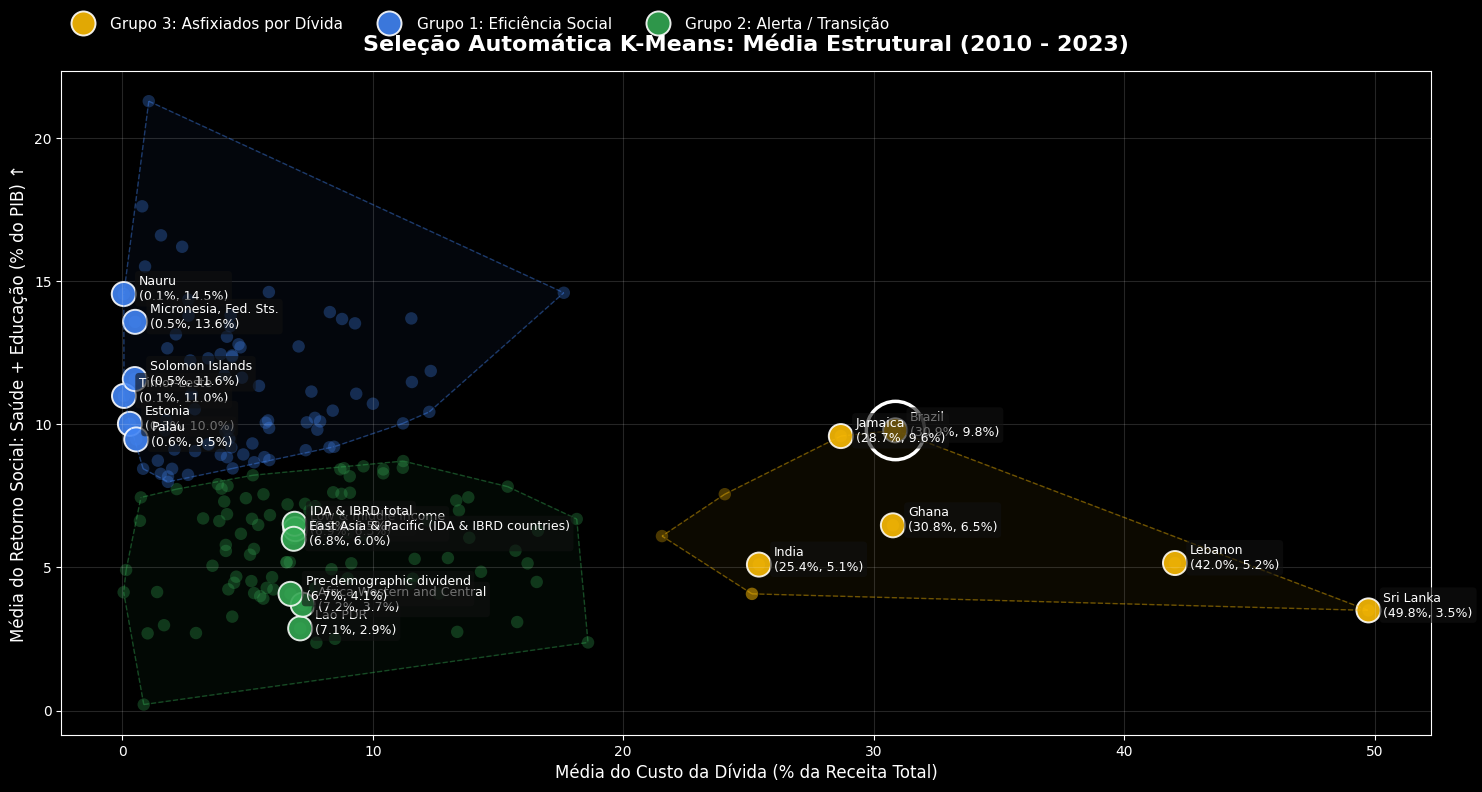

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import glob

print("Carregando o Banco Mundial inteiro...")
arq_edu = glob.glob('API_SE.XPD.TOTL.GD.ZS*.csv')
arq_sau = glob.glob('API_SH.XPD.GHED.GD.ZS*.csv')
arq_div = glob.glob('API_GC.XPN.INTP.RV.ZS*.csv')

df_edu = pd.read_csv(arq_edu[0], skiprows=4)
df_sau = pd.read_csv(arq_sau[0], skiprows=4)
df_div = pd.read_csv(arq_div[0], skiprows=4)

# 1. DEFINIÇÃO DO PERÍODO EXATO (2010 a 2023)
anos_analise = [str(ano) for ano in range(2010, 2024)]

# 2. CÁLCULO AUTOMÁTICO DA MÉDIA HISTÓRICA PARA O MUNDO TODO
def calcular_media_periodo(df, nome_coluna):
    anos_validos = [ano for ano in anos_analise if ano in df.columns]
    df_resumo = df[['Country Code', 'Country Name']].copy()
    df_resumo[nome_coluna] = df[anos_validos].mean(axis=1)
    return df_resumo

edu = calcular_media_periodo(df_edu, 'Educacao_PIB')
sau = calcular_media_periodo(df_sau, 'Saude_PIB')
div = calcular_media_periodo(df_div, 'Pagamento_Total_Divida')

# Consolidando a base global limpa
df_global = edu.merge(sau, on=['Country Code', 'Country Name']).merge(div, on=['Country Code', 'Country Name'])
df_global['Gasto_Social'] = df_global['Educacao_PIB'] + df_global['Saude_PIB']
df_global = df_global.dropna()

# 3. O ALGORITMO RODA ÀS CEGAS (K-MEANS)
X = df_global[['Pagamento_Total_Divida', 'Gasto_Social']]
X_padronizado = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_global['Cluster_ID'] = kmeans.fit_predict(X_padronizado)

# Auto-identificação e Nomenclatura Matemática
centroides = df_global.groupby('Cluster_ID')[['Pagamento_Total_Divida', 'Gasto_Social']].mean()
id_baixo_juros = centroides['Pagamento_Total_Divida'].idxmin()
id_alto_juros = centroides['Pagamento_Total_Divida'].idxmax()
id_medio_juros = [i for i in range(3) if i not in [id_baixo_juros, id_alto_juros]][0]

df_global['Nome_Cluster'] = df_global['Cluster_ID'].map({
    id_baixo_juros: 'Grupo 1: Eficiência Social',
    id_medio_juros: 'Grupo 2: Alerta / Transição',
    id_alto_juros: 'Grupo 3: Asfixiados por Dívida'
})

# 4. A SELEÇÃO INTELIGENTE: 6 PAÍSES POR GRUPO
# Pega os 6 melhores do Grupo 1 e os 6 piores do Grupo 3
top_eficientes = df_global[df_global['Cluster_ID'] == id_baixo_juros].nsmallest(6, 'Pagamento_Total_Divida')
top_asfixiados = df_global[df_global['Cluster_ID'] == id_alto_juros].nlargest(6, 'Pagamento_Total_Divida')

# Para o Grupo 2, pega os 6 países mais próximos do meio exato (mediana) do grupo
mediana_grupo2 = df_global[df_global['Cluster_ID'] == id_medio_juros]['Pagamento_Total_Divida'].median()
df_medio = df_global[df_global['Cluster_ID'] == id_medio_juros].copy()
df_medio['Distancia'] = abs(df_medio['Pagamento_Total_Divida'] - mediana_grupo2)
top_medios = df_medio.nsmallest(6, 'Distancia')

# Consolida os escolhidos pelo algoritmo
df_destaque = pd.concat([top_asfixiados, top_eficientes, top_medios])

# Trava de Segurança: Força o Brasil a aparecer com texto se o algoritmo não o colocou no Top 6 dos Asfixiados
if 'BRA' in df_global['Country Code'].values and 'BRA' not in df_destaque['Country Code'].values:
    df_destaque = pd.concat([df_destaque, df_global[df_global['Country Code'] == 'BRA']])

# 5. CONSTRUÇÃO VISUAL DO DASHBOARD
plt.figure(figsize=(15, 8))
plt.style.use('dark_background')
cores = {'Grupo 1: Eficiência Social': '#4285F4', 'Grupo 2: Alerta / Transição': '#34A853', 'Grupo 3: Asfixiados por Dívida': '#FBBC05'}

# Plota TODOS os países do mundo agrupados no fundo (bolhas opacas)
sns.scatterplot(data=df_global, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=80, alpha=0.3, edgecolor='none', legend=False)

# Plota com Destaque apenas os 18 países escolhidos dinamicamente pelo algoritmo
sns.scatterplot(data=df_destaque, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=300, alpha=0.9, edgecolor='white', legend='full')

# Desenha os polígonos baseados na realidade do mundo todo
for nome, grupo in df_global.groupby('Nome_Cluster'):
    pontos = grupo[['Pagamento_Total_Divida', 'Gasto_Social']].values
    if len(pontos) >= 3:
        hull = ConvexHull(pontos)
        for simplex in hull.simplices:
            plt.plot(pontos[simplex, 0], pontos[simplex, 1], color=cores[nome], linestyle='--', linewidth=1.0, alpha=0.4)
        plt.fill(pontos[hull.vertices, 0], pontos[hull.vertices, 1], color=cores[nome], alpha=0.05)

# Insere os Rótulos Textuais
for i in range(df_destaque.shape[0]):
    plt.annotate(f"{df_destaque['Country Name'].iloc[i]}\n({df_destaque['Pagamento_Total_Divida'].iloc[i]:.1f}%, {df_destaque['Gasto_Social'].iloc[i]:.1f}%)",
                 (df_destaque['Pagamento_Total_Divida'].iloc[i] + 0.6, df_destaque['Gasto_Social'].iloc[i] - 0.2), fontsize=9, color='white',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#111111", alpha=0.6, ec="none"))

# Destaca o Brasil com o círculo grosso para ser o centro da apresentação
brasil_data = df_destaque[df_destaque['Country Code'] == 'BRA']
if not brasil_data.empty:
    plt.plot(brasil_data['Pagamento_Total_Divida'].values[0], brasil_data['Gasto_Social'].values[0], 'o', ms=42, mec='white', mfc='none', mew=2.5)

# Ajustes Finais
plt.title('Seleção Automática K-Means: Média Estrutural (2010 - 2023)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Média do Custo da Dívida (% da Receita Total)', fontsize=12)
plt.ylabel('Média do Retorno Social: Saúde + Educação (% do PIB) ↑', fontsize=12)
plt.legend(bbox_to_anchor=(0, 1.05), loc='lower left', borderaxespad=0, ncol=3, frameon=False, fontsize=11)
plt.grid(True, alpha=0.15)
plt.tight_layout()

plt.show()

--- VALIDAÇÃO MATEMÁTICA: COEFICIENTE DE SILHUETA ---

Para K = 2, a nota da Silhueta é: 0.3745
Para K = 3, a nota da Silhueta é: 0.4148
Para K = 4, a nota da Silhueta é: 0.3619
Para K = 5, a nota da Silhueta é: 0.3880
Para K = 6, a nota da Silhueta é: 0.3933
Para K = 7, a nota da Silhueta é: 0.3992


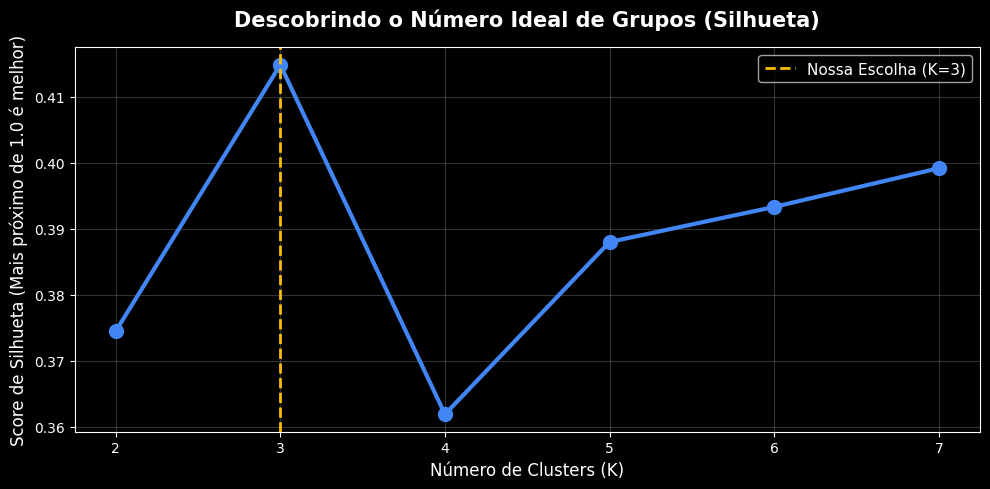

In [15]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("--- VALIDAÇÃO MATEMÁTICA: COEFICIENTE DE SILHUETA ---\n")

valores_silhueta = []
range_k = range(2, 8) # Vai testar de 2 até 7 grupos

# Loop testando cada possibilidade de K
for k in range_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_teste.fit_predict(X_padronizado)
    
    score = silhouette_score(X_padronizado, labels)
    valores_silhueta.append(score)
    print(f"Para K = {k}, a nota da Silhueta é: {score:.4f}")

# Gráfico para apresentar no trabalho
plt.figure(figsize=(10, 5))
plt.style.use('dark_background')

plt.plot(range_k, valores_silhueta, marker='o', color='#4285F4', linewidth=3, markersize=10)
plt.axvline(x=3, color='#FBBC05', linestyle='--', linewidth=2, label='Nossa Escolha (K=3)')

plt.title('Descobrindo o Número Ideal de Grupos (Silhueta)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Score de Silhueta (Mais próximo de 1.0 é melhor)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

In [14]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

print("Iniciando a Mineração de Regras (Apriori) com Binarização...\n")

# 1. Binarização pela Mediana (q=2)
df_regras = df_global[['Country Name', 'Pagamento_Total_Divida', 'Gasto_Social']].copy()
df_regras['Faixa_Divida'] = pd.qcut(df_regras['Pagamento_Total_Divida'], q=2, labels=['Dívida_Baixa', 'Dívida_Alta'])
df_regras['Faixa_Social'] = pd.qcut(df_regras['Gasto_Social'], q=2, labels=['Social_Baixo', 'Social_Alto'])

# 2. Matriz Transacional
df_transacional = pd.get_dummies(df_regras[['Faixa_Divida', 'Faixa_Social']])
df_transacional = df_transacional.astype(bool)

# 3. Algoritmo Apriori
itemsets_frequentes = apriori(df_transacional, min_support=0.15, use_colnames=True)

# 4. Regras (Exigindo Confiança superior a 55%)
regras = association_rules(itemsets_frequentes, metric="confidence", min_threshold=0.55)

regras_finais = regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
regras_finais['antecedents'] = regras_finais['antecedents'].apply(lambda x: list(x)[0])
regras_finais['consequents'] = regras_finais['consequents'].apply(lambda x: list(x)[0])
regras_finais = regras_finais.sort_values(by='confidence', ascending=False)

print("="*80)
print("AS REGRAS MAIS FORTES DO EFEITO TESOURA (Confiança > 55%)")
print("="*80)

for index, row in regras_finais.head(4).iterrows():
    antecedente = row['antecedents'].replace('Faixa_Divida_', '').replace('Faixa_Social_', '')
    consequente = row['consequents'].replace('Faixa_Divida_', '').replace('Faixa_Social_', '')
    
    print(f"REGRA: SE [{antecedente}] ---> ENTÃO [{consequente}]")
    print(f"   • Confiança  : {row['confidence']*100:.1f}% de certeza.")
    print(f"   • Suporte    : {row['support']*100:.1f}% dos países do mundo.")
    print(f"   • Lift       : {row['lift']:.2f}x (Força da correlação)\n")
        
if 'Brazil' in df_regras['Country Name'].values:
    brasil_d = df_regras[df_regras['Country Name'] == 'Brazil']['Faixa_Divida'].values[0]
    brasil_s = df_regras[df_regras['Country Name'] == 'Brazil']['Faixa_Social'].values[0]
    print("-" * 80)
    print(f"DIAGNÓSTICO DO BRASIL: Anomalia detectada ({brasil_d} e {brasil_s}).")
    print("="*80)

Iniciando a Mineração de Regras (Apriori) com Binarização...

AS REGRAS MAIS FORTES DO EFEITO TESOURA (Confiança > 55%)
REGRA: SE [Social_Alto] ---> ENTÃO [Dívida_Baixa]
   • Confiança  : 63.8% de certeza.
   • Suporte    : 31.9% dos países do mundo.
   • Lift       : 1.28x (Força da correlação)

REGRA: SE [Dívida_Baixa] ---> ENTÃO [Social_Alto]
   • Confiança  : 63.8% de certeza.
   • Suporte    : 31.9% dos países do mundo.
   • Lift       : 1.28x (Força da correlação)

REGRA: SE [Social_Baixo] ---> ENTÃO [Dívida_Alta]
   • Confiança  : 63.8% de certeza.
   • Suporte    : 31.9% dos países do mundo.
   • Lift       : 1.28x (Força da correlação)

REGRA: SE [Dívida_Alta] ---> ENTÃO [Social_Baixo]
   • Confiança  : 63.8% de certeza.
   • Suporte    : 31.9% dos países do mundo.
   • Lift       : 1.28x (Força da correlação)

--------------------------------------------------------------------------------
DIAGNÓSTICO DO BRASIL: Anomalia detectada (Dívida_Alta e Social_Alto).


In [16]:
# ==============================================================================
# CÉLULA 3: PREPARAÇÃO DA BASE PRINCIPAL (Média Estrutural 2010 - 2023)
# ==============================================================================

# 1. DEFINIÇÃO DA JANELA HISTÓRICA 
anos_analise = [str(ano) for ano in range(2010, 2024)]

# 2. FUNÇÃO DE EXTRAÇÃO DA MÉDIA DE LONGO PRAZO
def calcular_media_periodo(df, nome_coluna):
    # Verifica quais anos realmente existem na base para evitar erros
    anos_validos = [ano for ano in anos_analise if ano in df.columns]
    df_resumo = df[['Country Code', 'Country Name']].copy()
    
    # Calcula a média do país considerando apenas a janela de 2010 a 2023
    df_resumo[nome_coluna] = df[anos_validos].mean(axis=1)
    return df_resumo

print(f"Calculando a média estrutural dos países entre {anos_analise[0]} e {anos_analise[-1]}...")

# 3. APLICANDO A MÉDIA PARA CADA INDICADOR
edu = calcular_media_periodo(df_edu, 'Educacao_PIB')
sau = calcular_media_periodo(df_sau, 'Saude_PIB')
div = calcular_media_periodo(df_div, 'Pagamento_Total_Divida')

# 4. CONSOLIDANDO TUDO NA BASE GLOBAL
df_global = edu.merge(sau, on=['Country Code', 'Country Name']).merge(div, on=['Country Code', 'Country Name'])

# Criando a coluna de Gasto Social (Saúde + Educação)
df_global['Gasto_Social'] = df_global['Educacao_PIB'] + df_global['Saude_PIB']

# Limpeza final: remove países que não relataram os dados no período (evita falha na IA)
df_global = df_global.dropna()

print(f"Base de dados unificada com sucesso! Total de países aptos para análise: {df_global.shape[0]}")

# Exibe as 5 primeiras linhas para mostrar a tabela limpa na apresentação
display(df_global.head())

Calculando a média estrutural dos países entre 2010 e 2023...
Base de dados unificada com sucesso! Total de países aptos para análise: 188


,Country Code,Country Name,Educacao_PIB,Saude_PIB,Pagamento_Total_Divida,Gasto_Social
1,AFE,Africa Eastern and Southern,4.443016,2.776206,7.297192,7.219222
2,AFG,Afghanistan,3.604786,0.524946,0.054089,4.129732
3,AFW,Africa Western and Central,2.915802,0.779208,7.203257,3.695010
4,AGO,Angola,2.814184,1.266945,12.628336,4.081129
5,ALB,Albania,3.321023,2.812692,9.653688,6.133714
